In [3]:
# ================================
# TITANIC SURVIVAL PREDICTION
# Complete ML Project
# ================================

# Step 1 — Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [4]:
# Step 2 — Load the data
df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (891, 12)

First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0       

In [5]:
# Step 3 — Clean the data
df['Age'] = df['Age'].fillna(df['Age'].mean())
df = df.drop(columns=['Cabin'])
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [6]:
# Step 4 — Prepare the data
# Convert text to numbers
df['Sex'] = df['Sex'].map({'male': 1, 'female': 0})
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# Select features and target
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
X = df[features]
y = df['Survived']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 712
Testing samples: 179


In [7]:
# Step 5 — Train and evaluate the model
model = DecisionTreeClassifier(max_depth=4)
model.fit(X_train, y_train)

# Accuracy on training and testing
train_accuracy = accuracy_score(y_train, model.predict(X_train))
test_accuracy = accuracy_score(y_test, model.predict(X_test))

print(f"Training accuracy: {train_accuracy:.2f}")
print(f"Testing accuracy:  {test_accuracy:.2f}")

# Cross validation
scores = cross_val_score(model, X, y, cv=5)
print(f"\nCross validation scores: {scores}")
print(f"Average accuracy: {scores.mean():.2f}")

# Confusion matrix
cm = confusion_matrix(y_test, model.predict(X_test))
print(f"\nConfusion Matrix:")
print(cm)

Training accuracy: 0.84
Testing accuracy:  0.80

Cross validation scores: [0.75418994 0.8258427  0.80898876 0.78651685 0.84269663]
Average accuracy: 0.80

Confusion Matrix:
[[96  9]
 [27 47]]


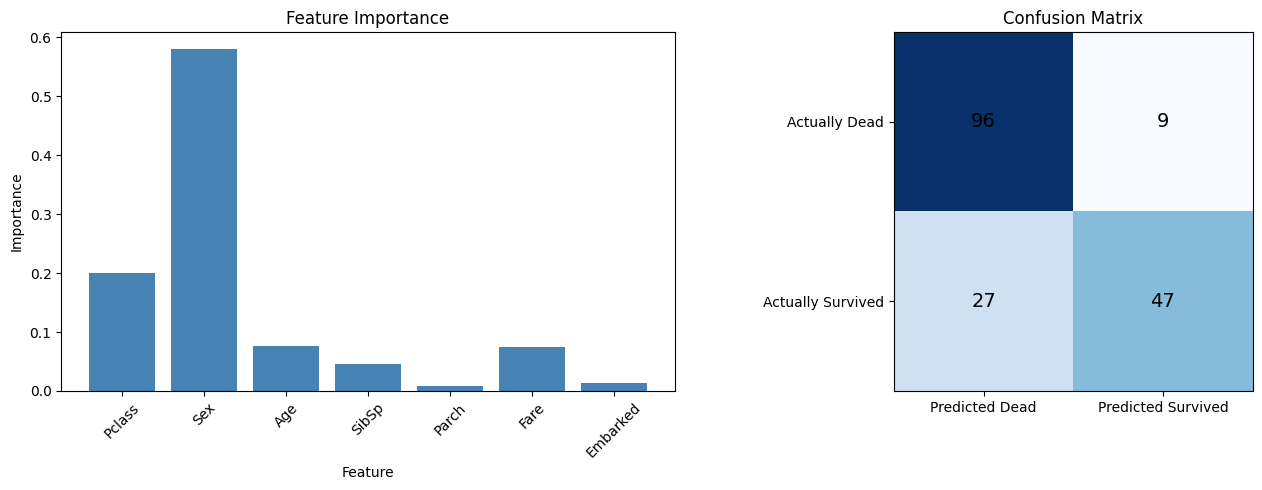

In [8]:
# Step 6 — Visualize results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 - Feature importance
importance = model.feature_importances_
axes[0].bar(features, importance, color='steelblue')
axes[0].set_title("Feature Importance")
axes[0].set_xlabel("Feature")
axes[0].set_ylabel("Importance")
axes[0].tick_params(axis='x', rotation=45)

# Chart 2 - Confusion matrix
axes[1].imshow(cm, cmap='Blues')
axes[1].set_title("Confusion Matrix")
axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(['Predicted Dead', 'Predicted Survived'])
axes[1].set_yticklabels(['Actually Dead', 'Actually Survived'])
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, cm[i, j], ha='center', va='center', color='black', fontsize=14)

plt.tight_layout()
plt.show()